In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import os
import sdeint
from scipy.linalg import sqrtm

# Define model parameters
N = 0.44 * 1e12
q = 0.198
T2 = 0.87 * 1e-3
g_D = 0.00177
Sph = 96
w0 = 2 * np.pi * 1e4
h = 50 * 1e-9
tf = 2.
dc = 0.0
tau = 0.1

# Derived parameters
Nq = N * q
xc = np.sqrt(2 / Nq)
yc = np.sqrt(2 / (g_D**2 * Nq))
sig_v = np.sqrt(2 * Sph / (g_D**2 * Nq * h))

# Initial state
x = np.array([0, np.sqrt(2 / (q * N)) * 0.5 * N, w0 * T2])

# State transition function
def f_x(x, t):
    return np.array([-x[0] + x[2] * x[1], -x[2] * x[0] - x[1], 0])

# Jacobian for EKF
def F_jacobian(x, t):
    return np.array([[-1, x[2], x[1]], [-x[2], -1, -x[0]], [0, 0, 0]])

# Intrinsic noise
def get_intrinsic_noise(dt):
    return np.array([np.sqrt(dt), np.sqrt(dt), np.sqrt(dt)]) * np.random.randn(3)

def get_G(x, t):
    return np.diag([np.sqrt(2), np.sqrt(2), np.sqrt(dc)])

def step(x0, t, dt, num_steps=20, type=None):
    t_span = np.linspace(t, t + dt, num_steps)
    dW = np.array([get_intrinsic_noise(dt) for _ in t_span[1:]])
    if type is None:
        x = sdeint.itoSRI2(f=f_x, G=get_G, y0=x0, tspan=t_span, dW=dW)
    return x[-1]

def simulate(t_max, dt, x0, xs, num_steps=20, type=None):
    time_arr = np.arange(0, t_max, dt)
    for index, time in enumerate(tqdm.tqdm(time_arr, desc='pid:%r' % os.getpid())):
        x = step(x0, time, dt, num_steps, type=type)
        xs[index] = x
        x0 = x
    return xs

# CKF Implementation
def cubature_points(x, P):
    n = len(x)
    Xi = np.zeros((n, 2 * n))
    W = np.ones(2 * n) / (2 * n)
    U = sqrtm(n * P)
    for i in range(n):
        Xi[:, i] = x + U[:, i]
        Xi[:, n + i] = x - U[:, i]
    return Xi, W

def cubature_kalman_filter(x_est, P_est, Q, R, t_meas):
    n = len(x_est)
    trajectory = []
    measurements = []
    for t in t_meas:
        Xi, W = cubature_points(x_est, P_est)
        X_pred = np.array([f_x(Xi[:, j], t) for j in range(2 * n)]).T
        x_pred = np.sum(W * X_pred, axis=1)
        P_pred = Q + sum(W[j] * np.outer(X_pred[:, j] - x_pred, X_pred[:, j] - x_pred) for j in range(2 * n))
        Z_pred = X_pred[0, :]
        z_pred = np.sum(W * Z_pred)
        P_zz = R + sum(W[j] * (Z_pred[j] - z_pred) ** 2 for j in range(2 * n))
        P_xz = sum(W[j] * np.outer(X_pred[:, j] - x_pred, Z_pred[j] - z_pred) for j in range(2 * n))
        K = P_xz / P_zz
        z_meas = x_est[0] + np.random.normal(0, np.sqrt(R))
        x_est = x_pred + K * (z_meas - z_pred)
        P_est = P_pred - K[:, None] * P_zz * K
        trajectory.append(x_est)
        measurements.append(z_meas)
    return np.array(trajectory), np.array(measurements)

# EKF Implementation
def extended_kalman_filter(x_est, P_est, Q, R, t_meas):
    trajectory = []
    measurements = []
    for t in t_meas:
        F = F_jacobian(x_est, t)
        x_pred = f_x(x_est, t)
        P_pred = F @ P_est @ F.T + Q
        H = np.array([[1, 0, 0]])
        z_pred = H @ x_pred
        P_zz = H @ P_pred @ H.T + R
        P_xz = P_pred @ H.T
        K = P_xz / P_zz
        z_meas = x_est[0] + np.random.normal(0, np.sqrt(R))
        x_est = x_pred + K * (z_meas - z_pred)
        P_est = P_pred - K[:, None] * P_zz * K
        trajectory.append(x_est)
        measurements.append(z_meas)
    return np.array(trajectory), np.array(measurements)

# Run Filters
t_meas = np.linspace(0, tf, int(tf / h))
x_est = np.copy(x)
P_est = np.eye(len(x)) * 0.1
Q = np.eye(len(x)) * 0.01
R = np.eye(1) * sig_v**2

# ckf_trajectory, ckf_measurements = cubature_kalman_filter(x_est, P_est, Q, R, t_meas)
ekf_trajectory, ekf_measurements = extended_kalman_filter(x_est, P_est, Q, R, t_meas)

# Plot results
plt.figure()
# plt.plot(t_meas, ckf_trajectory[:, 0], label="CKF Estimated x")
plt.plot(t_meas, ekf_trajectory[:, 0], label="EKF Estimated x", linestyle='dashed')
# plt.scatter(t_meas, ckf_measurements, color='red', s=10, label="Measurements")
plt.xlabel("Time [ms]")
plt.ylabel("State x")
plt.legend()
plt.title("CKF vs EKF Estimation")
plt.show()


C:\Users\Klaudia\AppData\Local\Temp\ipykernel_20008\888394845.py:35: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return np.array([[-1, x[2], x[1]], [-x[2], -1, -x[0]], [0, 0, 0]])
C:\Users\Klaudia\AppData\Local\Temp\ipykernel_20008\888394845.py:31: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return np.array([-x[0] + x[2] * x[1], -x[2] * x[0] - x[1], 0])
C:\Users\Klaudia\AppData\Local\Temp\ipykernel_20008\888394845.py:98: RuntimeWarning: overflow encountered in multiply
  P_pred = F @ P_est @ F.T + Q
C:\Users\Klaudia\AppData\Local\Temp\ipykernel_2

KeyboardInterrupt: 

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import os
import sdeint
from scipy.linalg import sqrtm

In [24]:
# Parameters
N = 0.44 * 1e12  # Number of atoms
q = 0.198        # Parameter
T2 = 0.87 * 1e-3  # Relaxation time in s
# T2 = 1e-1
g_D = 0.00177    # [pA]
# g_D = 0.1
Sph = 96         # Photon noise PSD [pA^2/Hz]
w0 = 2 * np.pi * 1e4  # Mean value of the Larmor in OU process
w01 = w0 * T2  # in non dimensional units
dt_sim = 50 * 1e-9    # Time step is the solver time step not the probing time!whath out
tf = 2.        # Final time in [ms]
nsteps = int(tf * 1e-3 / dt_sim)  # Number of steps in simulation
dt_sim_non_dim = dt_sim / T2      # Time step in non-dimensional units
dc = 0.0
# dc = 0.01         # Diffusion constant of the OU process 0.01 for fluctuating
# tau = 0.001
tau=0.1
measure_every_nth = 100
meas_probing_rate = h*measure_every_nth  # in s
#TRANSFORM DATA - compute coefficients
Nq = N * q
xc = np.sqrt(2 / Nq)
yc = np.sqrt(2 / (g_D**2 * Nq))
sig_v = np.sqrt(2 * Sph / (g_D**2 * Nq * meas_probing_rate))
meas_probing_rate_unitless = meas_probing_rate/T2

# Time constant of the OU process in non-dimensional units
G = np.diag([np.sqrt(2), np.sqrt(2), np.sqrt(dc)])  # Matrix G
D = np.array([[2, 0, 0], [0, 2, 0], [0, 0, dc]])

xc2 = xc*xc
sgv2 = sig_v**2  # measurement noise variance

# Time vector in [ms] simulation
t = np.arange(0, tf/(T2*1e3), dt_sim_non_dim)
t_meas = np.arange(0, tf/(T2*1e3), meas_probing_rate_unitless)

# Initial condition (simulation)
x = np.array([0, np.sqrt(2 / (q * N)) * 0.5 * N, w0 * T2])


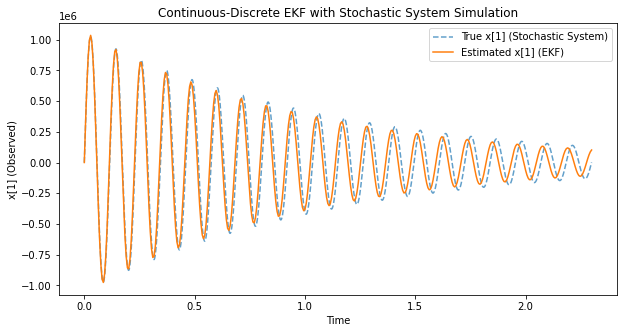

In [26]:


# Define system dynamics (drift term)
def f_x(x, t):
    return np.array([-x[0] + x[2] * x[1], -x[2] * x[0] - x[1], 0])

# Jacobian of f_x
def F_jacobian(x, t):
    return np.array([[-1, x[2], x[1]],
                     [-x[2], -1, -x[0]],
                     [0, 0, 0]])

# Measurement matrix
H = np.array([[0, 1, 0]])  # y = x[1]

# Process and measurement noise
Q = np.diag([2, 2, dc])  # Process noise covariance
R = sig_v  # Measurement noise variance

# Function to simulate the true stochastic system using Euler-Maruyama
def simulate_stochastic_system(x0, t_eval, dt):
    """Simulates the stochastic system using the Euler-Maruyama method."""
    num_steps = len(t_eval)
    x_true = np.zeros((num_steps, len(x0)))
    x_true[0] = x0

    for i in range(1, num_steps):
        t = t_eval[i - 1]
        dt_step = t_eval[i] - t_eval[i - 1]

        # Drift term
        drift = f_x(x_true[i - 1], t) * dt_step

        # Diffusion term (Wiener process noise)
        diffusion = np.sqrt(Q) @ np.random.normal(0, np.sqrt(dt_step), size=x0.shape)

        # Euler-Maruyama step
        x_true[i] = x_true[i - 1] + drift + diffusion

    return x_true

# Function to solve coupled differential equations for state and covariance
def state_cov_ode(t, y):
    """Solves the coupled ODE for state and covariance propagation."""
    x = y[:3]  # Extract state
    P_flat = y[3:]  # Extract flattened covariance matrix

    # Reshape P into matrix form
    P = P_flat.reshape((3, 3))

    # Compute system Jacobian at x
    F = F_jacobian(x, t)

    # State derivative
    dxdt = f_x(x, t)

    # Covariance derivative: dP/dt = F P + P F^T + Q
    dPdt = F @ P + P @ F.T + Q

    # Flatten dPdt for ODE solver
    return np.concatenate([dxdt, dPdt.flatten()])

# Continuous-discrete EKF function
def continuous_discrete_ekf(x0, P0, t_span, dt, measurements, measurement_times):
    x_est = x0.copy()
    P_est = P0.copy()

    states = [x_est]
    covariances = [P_est]
    times = [t_span[0]]

    t = t_span[0]
    meas_idx = 0

    while t < t_span[1]:
        t_next = min(t + dt, t_span[1])

        # Solve ODE for state and covariance propagation
        y0 = np.concatenate([x_est, P_est.flatten()])
        sol = solve_ivp(state_cov_ode, (t, t_next), y0, method='RK45', max_step=dt/100)

        # Extract the latest state and covariance
        x_est = sol.y[:3, -1]
        P_est = sol.y[3:, -1].reshape((3, 3))

        # Discrete-time update if measurement is available
        if meas_idx < len(measurement_times) and np.isclose(t_next, measurement_times[meas_idx]):
            y_meas = measurements[meas_idx]
            meas_idx += 1

            # Compute Kalman gain
            S = H @ P_est @ H.T + R
            K = P_est @ H.T @ np.linalg.inv(S)

            # Update state estimate
            y_pred = H @ x_est
            x_est = x_est + K @ (y_meas - y_pred)

            # Update covariance estimate
            P_est = (np.eye(len(x0)) - K @ H) @ P_est

        # Store results
        states.append(x_est)
        covariances.append(P_est)
        times.append(t_next)

        # Update time
        t = t_next

    return np.array(times), np.array(states), np.array(covariances)

# Initial conditions
# x0 = np.array([1.0, 0.5, 2.0])
# P0 = np.diag([0.1, 0.1, 0.01])
dw0 = 0.01
dJ = 0.01
x0 = x
x0_ekf = np.array([0, 0.5 * xc * N * (1 + dJ), w0 * (1 + dw0)*T2])
P0_ekf = np.diag([
    (0.5 * xc * N * dJ/3)**2,
    (0.5 * xc * N * dJ/3)**2,
    (w0 * T2 * dw0/3)**2
])

# Simulation parameters
t_start, t_end = 0, tf/(T2*1e3)
dt = dt_sim_non_dim # Small step size for SDE simulation
t_eval = np.arange(t_start, t_end, dt)

# Simulate the true stochastic system
x_true = simulate_stochastic_system(x0, t_eval, dt)

# Generate noisy measurements from the simulated system
measurement_times = np.arange(0, t_end, meas_probing_rate_unitless)  # Measurements every 0.5s
measurement_indices = np.searchsorted(t_eval, measurement_times)
measurements = x_true[measurement_indices, 1] + np.random.normal(0, np.sqrt(R), len(measurement_times))

# Run CD-EKF
times, states, covariances = continuous_discrete_ekf(x0_ekf, P0_ekf, (t_start, t_end), meas_probing_rate_unitless , measurements, measurement_times)
# Plot Results
plt.figure(figsize=(10, 5))
plt.plot(t_eval, x_true[:, 0], label="True x[1] (Stochastic System)", linestyle='dashed', alpha=0.7)
plt.plot(times, states[:, 0], label="Estimated x[1] (EKF)")
# plt.scatter(measurement_times, measurements, color='red', label="Noisy Measurements", zorder=3)
plt.xlabel("Time")
plt.ylabel("x[1] (Observed)")
plt.legend()
plt.title("Continuous-Discrete EKF with Stochastic System Simulation")
plt.show()
